In [1]:
import pandas as pd
import sqlite3

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## analyze only the users and not the admins


In [3]:
pd.read_sql('SELECT name FROM sqlite_master WHERE type="table"', connection)

,name
0,pageviews
1,checker
2,deadlines


In [4]:
pd.read_sql('SELECT * FROM pageviews LIMIT 2', connection)

,index,uid,datetime
0,0,admin_1,2020-04-17 12:01:08.463179
1,1,admin_1,2020-04-17 12:01:23.743946


In [5]:
pd.read_sql('SELECT * FROM checker LIMIT 2', connection)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1


In [6]:
query = '''
WITH views AS (
    SELECT DATE(datetime) AS date, COUNT(*) as views
    FROM pageviews
    WHERE uid LIKE 'user%'
    GROUP BY date
),
commits AS (
    SELECT DATE(timestamp) AS date, COUNT(*) as commits
    FROM checker
    WHERE uid LIKE 'user%'
    GROUP BY date
)
SELECT views.date, views.views, commits.commits
FROM views
JOIN commits ON views.date = commits.date
WHERE views.views > 0 AND commits.commits > 0;     
'''

In [7]:
df = pd.read_sql(query, connection)
df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


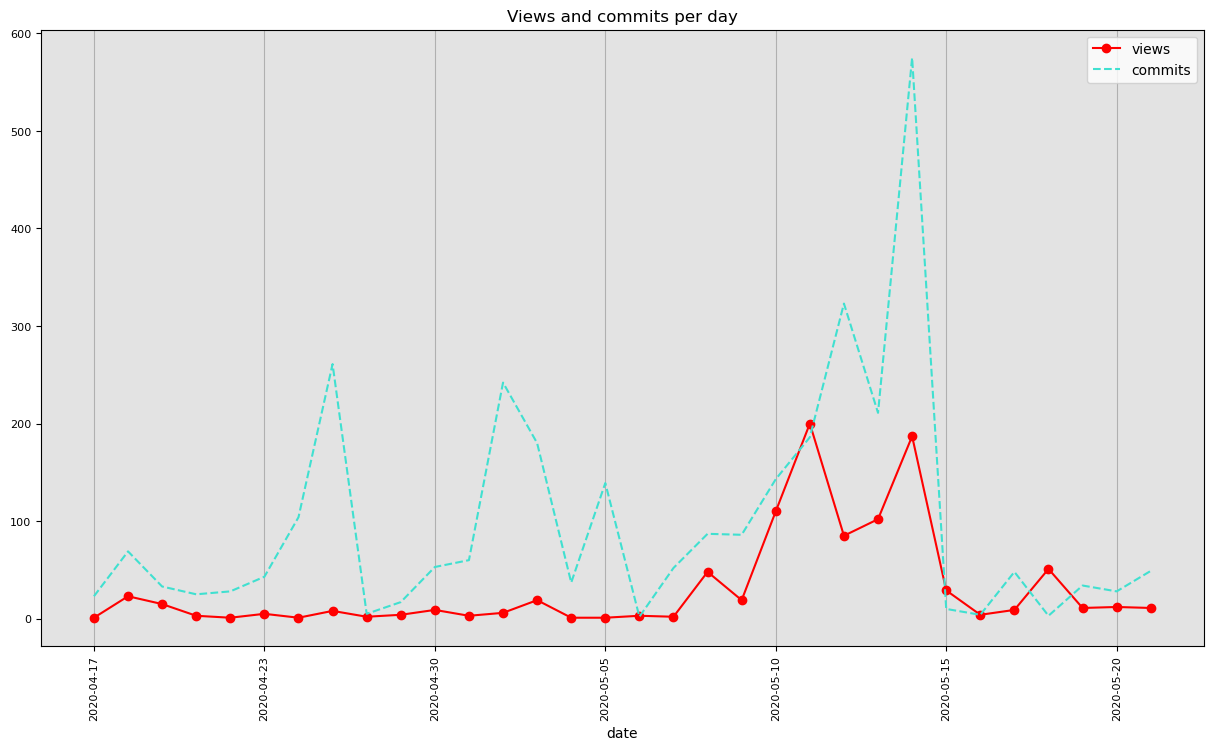

In [11]:
ax = df.plot(x='date', y='views', color='red', figsize=(15,8), fontsize=8, style='o-')
df.plot(x='date', y='commits', label='commits', color='turquoise', ax=ax, linestyle='--')

ax.set_title('Views and commits per day')
ax.set_xlabel('date')
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='x')
ax.set_facecolor('#E3E3E3')

## How many times was the number of views larger than 150?

In [9]:
df[df['views'] > 150]

,date,views,commits
21,2020-05-11,200,186
24,2020-05-14,187,575


The answer is 2.

In [10]:
connection.close()